# KaroSpace Pseudobulk DE Audit

This notebook independently reproduces the current KaroSpace shared-fit pseudobulk DE calculation for one selected category-versus-category contrast.

KaroSpace aggregates raw counts by `replicate` and annotation, retains categories with enough pseudobulk samples, fits one shared `~ _pb_replicate + _pb_group` DESeq2 model, and extracts the selected `source - reference` contrast. The same model also provides balanced-rest contrasts: one category minus the equally weighted mean of all other retained category coefficients.

PCA/distance diagnostics are optional. With `pseudobulk_diagnostics="pairwise"`, KaroSpace stores one payload for each unordered selected pair at `pseudobulk_de[annotation]._summary.pair_diagnostics[source][reference]`; it contains only those two annotations. With `"none"` (the default), no PCA/distance payload is embedded.


In [ ]:
# Parameters: edit this cell
H5AD_PATH = "/Users/bastien.herve/Downloads/RRMAP2_xenium_all_samples.cellcharter.companion.ready.with_metadata.rerun.with_AnnoL1Curated_with_Region_Anno2to4Updated.h5ad"

# Same conceptual inputs as the CLI/API pseudobulk cluster DE path.
GROUPBY = "Anno_L1_curated"
REPLICATE = "meta_sample_id"
SOURCE = "OPC"  # category shown as positive log2FC
REFERENCE = "Schwann cell"  # baseline category

# Counts and filtering.
COUNTS_LAYER = "counts"  # use None for adata.X
MIN_CELLS = 20  # KaroSpace's fixed minimum cells per pseudobulk sample
MIN_CELL_COUNTS = 100  # --pseudobulk-min-cell-counts
MIN_GENE_COUNTS = 100  # --pseudobulk-min-gene-counts
MIN_REPLICATES = 3
MIN_PCT_EXPRESSED = 0.5  # values >1 are interpreted as percentages, e.g. 10 -> 0.10

# DE settings.
P_ADJUST_METHOD = "fdr_bh"  # fdr_bh, bonferroni, holm, none
PADJ_CUTOFF = 0.05
LOG2FC_CUTOFF = 2
DESEQ2_FIT_TYPE = "mean"  # parametric or mean
N_CPUS = 4

# Diagnostic plot settings.
MAX_DIAGNOSTIC_GENES = 1000
MA_RAW_PVALUE_GREEN_CUTOFF = 0.05

In [ ]:
import json
import re
import warnings
from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.sparse as sp
from scipy.cluster.hierarchy import dendrogram, leaves_list, linkage
from scipy.spatial.distance import pdist, squareform

from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 30)


def normalize_pct_threshold(value):
    threshold = float(value or 0.0)
    if threshold > 1.0:
        threshold /= 100.0
    return min(max(threshold, 0.0), 1.0)


def adjust_pvalues(pvalues, method="fdr_bh"):
    method = str(method or "fdr_bh").strip().lower().replace("-", "_")
    p = np.asarray(pvalues, dtype=float)
    adjusted = np.full(p.shape, np.nan, dtype=float)
    finite = np.isfinite(p)
    if not finite.any():
        return adjusted
    vals = np.clip(p[finite], 0.0, 1.0)
    n = vals.size
    if method in {"none", "raw", "pvalue", "pvalues"}:
        out = vals
    elif method in {"bonferroni", "bonf"}:
        out = np.minimum(vals * n, 1.0)
    elif method in {"holm", "holm_bonferroni"}:
        order = np.argsort(vals)
        ranked = vals[order]
        holm = np.maximum.accumulate((n - np.arange(n)) * ranked)
        holm = np.minimum(holm, 1.0)
        out = np.empty_like(vals)
        out[order] = holm
    else:
        # Benjamini-Hochberg FDR, same logic as KaroSpace pseudobulk.py.
        order = np.argsort(vals)
        ranked = vals[order]
        bh = ranked * n / np.arange(1, n + 1)
        bh = np.minimum.accumulate(bh[::-1])[::-1]
        bh = np.minimum(bh, 1.0)
        out = np.empty_like(vals)
        out[order] = bh
    out[(out == 0) & np.isfinite(out)] = np.nextafter(0.0, 1.0)
    adjusted[finite] = out
    return adjusted


def to_dense_counts(matrix):
    if sp.issparse(matrix):
        matrix = matrix.toarray()
    counts = np.asarray(matrix, dtype=float)
    counts[~np.isfinite(counts)] = 0
    counts[counts < 0] = 0
    return np.rint(counts).astype(int)


def cell_count_mask(matrix, min_cell_counts):
    threshold = max(0, int(min_cell_counts))
    if threshold == 0:
        return np.ones(int(matrix.shape[0]), dtype=bool)
    totals = (
        np.asarray(matrix.sum(axis=1)).ravel()
        if sp.issparse(matrix)
        else np.asarray(matrix).sum(axis=1)
    )
    totals = np.asarray(totals, dtype=float)
    return np.isfinite(totals) & (totals >= threshold)


def filter_pseudobulk_genes(counts, gene_names, min_gene_counts):
    threshold = max(0, int(min_gene_counts))
    if threshold == 0:
        return np.asarray(counts), list(gene_names)
    totals = np.asarray(counts, dtype=float).sum(axis=0)
    keep = np.isfinite(totals) & (totals >= threshold)
    return np.asarray(counts)[:, keep], [
        gene for gene, include in zip(gene_names, keep) if include
    ]


def positive_fraction(matrix, mask, gene_indices):
    gene_indices = np.asarray(gene_indices, dtype=int)
    if not np.any(mask) or gene_indices.size == 0:
        return [np.nan] * gene_indices.size
    sub = matrix[mask][:, gene_indices]
    if sp.issparse(sub):
        return np.asarray((sub > 0).mean(axis=0)).ravel().astype(float)
    return np.mean(np.asarray(sub) > 0, axis=0).astype(float)


def format_p(value):
    value = float(value) if np.isfinite(value) else np.nan
    if not np.isfinite(value):
        return "nan"
    if 0 < value < 0.001:
        return f"{value:.2e}"
    return f"{value:.6g}"

In [7]:
adata = ad.read_h5ad(H5AD_PATH)
print(adata)

required_obs = [GROUPBY, REPLICATE]
missing = [col for col in required_obs if col not in adata.obs.columns]
if missing:
    raise KeyError(f"Missing obs columns: {missing}")

if COUNTS_LAYER and COUNTS_LAYER not in adata.layers:
    warnings.warn(f"COUNTS_LAYER={COUNTS_LAYER!r} not found; falling back to adata.X")
    count_matrix_raw = adata.X
    counts_layer_used = "X"
elif COUNTS_LAYER:
    count_matrix_raw = adata.layers[COUNTS_LAYER]
    counts_layer_used = COUNTS_LAYER
else:
    count_matrix_raw = adata.X
    counts_layer_used = "X"

count_matrix = count_matrix_raw
print(f"Counts source: {counts_layer_used}")
print(f"Genes in AnnData: {adata.n_vars:,}")

AnnData object with n_obs × n_vars = 1384881 × 5101
    obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'run_id', 'sample_id', 'sample_label', 'xenium_output', 'instrument_or_flowcell', 'cassette_or_slide_id', 'run_date', 'cell_id', 'kmeans_split_id', 'n_counts', 'n_genes', 'leiden_1.5', 'leiden_2', 'leiden_2.5', 'leiden_3', 'leiden_3.5', 'leiden_4.0', 'CellCharter_5', 'CellCharter_10', 'CellCharter_15', 'CellCharter_20', 'CellCharter_25', 'CellCharter_30', 'CellCharter_35', 'CellCharter_40', 'CellCharter_45', 'CellCharter_50', 'meta_sample_id', 'sample_name', 'stage', 'condition', 'day_of_sacrifice', 'score_sacrifice', 'region', 'sex', 'model', 'polygon_label', 'polygon_id', 'polygon_remove', 'polygon_remove_0', 'polygon_remove_1', 'Anno_L1', 'CellCharter_60', 

In [ ]:
# Build valid cells and category values exactly like the KaroSpace pseudobulk path.
group_col = adata.obs[GROUPBY]
if pd.api.types.is_numeric_dtype(group_col):
    raise TypeError(
        f"GROUPBY={GROUPBY!r} is numeric; pseudobulk DE expects a categorical annotation"
    )
if not isinstance(group_col.dtype, pd.CategoricalDtype):
    group_col = group_col.astype("category")

categories = [str(cat) for cat in group_col.cat.categories]
print(f"{GROUPBY}: {len(categories)} categories")
print(categories[:30])

if str(SOURCE) not in categories or str(REFERENCE) not in categories:
    raise ValueError(
        f"SOURCE={SOURCE!r} and REFERENCE={REFERENCE!r} must both be in categories"
    )

rep_values = adata.obs[REPLICATE].astype(str)
group_values = group_col.astype(str)
valid = rep_values.notna().to_numpy() & group_values.notna().to_numpy()
valid &= np.asarray(group_col.cat.codes.to_numpy() >= 0, dtype=bool)
valid &= cell_count_mask(count_matrix, MIN_CELL_COUNTS)

valid_indices = np.flatnonzero(valid)
rep_valid = rep_values.iloc[valid_indices].astype(str).to_numpy()
group_valid = group_values.iloc[valid_indices].astype(str).to_numpy()

sample_keys = []
sample_index = {}
rows = np.empty(valid_indices.size, dtype=np.int64)
for i, (rep, grp) in enumerate(zip(rep_valid, group_valid)):
    key = (str(rep), str(grp))
    idx = sample_index.get(key)
    if idx is None:
        idx = len(sample_keys)
        sample_index[key] = idx
        sample_keys.append(key)
    rows[i] = idx

incidence = sp.csr_matrix(
    (np.ones(valid_indices.size, dtype=np.float64), (rows, valid_indices)),
    shape=(len(sample_keys), adata.n_obs),
)
aggregate = to_dense_counts(incidence @ count_matrix)
cell_counts = np.bincount(rows, minlength=len(sample_keys)).astype(int)

pb_meta = pd.DataFrame(
    {
        "_pb_replicate": [key[0] for key in sample_keys],
        "_pb_group": [key[1] for key in sample_keys],
        "n_cells": cell_counts,
    },
    index=[f"pb_{i}" for i in range(len(sample_keys))],
)

display(pb_meta.head())
print(f"Pseudobulk samples: {len(pb_meta):,}")
print(
    f"Aggregate matrix: {aggregate.shape[0]:,} samples x {aggregate.shape[1]:,} genes"
)

Anno_L1_curated: 19 categories
['Astrocyte', 'B cell', 'DC', 'Doublet', 'Endothelial', 'Ependymal cell', 'Epithelial', 'Fibroblast', 'Muscle cell', 'Myeloid', 'NK/DC', 'Neuron', 'Neutrophil', 'OPC', 'Oligodendrocyte', 'Schwann cell', 'T cell', 'T_B_doublet', 'VSMC']


,_pb_replicate,_pb_group,n_cells
pb_0,G3_L1_0,Schwann cell,128
pb_1,G3_L1_0,Astrocyte,1121
pb_2,G3_L1_0,Neuron,1728
pb_3,G3_L1_0,Oligodendrocyte,2460
pb_4,G3_L1_0,Endothelial,833


Pseudobulk samples: 2,541
Aggregate matrix: 2,541 samples x 5,101 genes


In [ ]:
# Select the requested source/reference contrast and retain the full shared-fit cohort.
source = str(SOURCE)
reference = str(REFERENCE)
min_cells = int(MIN_CELLS)
min_replicates = max(2, int(MIN_REPLICATES))

sufficient_pb = pb_meta[
    pb_meta["_pb_group"].isin(categories) & (pb_meta["n_cells"] >= min_cells)
]
retained_categories = [
    category
    for category in categories
    if sufficient_pb.loc[
        sufficient_pb["_pb_group"] == category, "_pb_replicate"
    ].nunique()
    >= min_replicates
]
if source not in retained_categories or reference not in retained_categories:
    raise ValueError(f"SOURCE and REFERENCE must be retained: {retained_categories}")

model_mask = pb_meta["_pb_group"].isin(retained_categories) & (
    pb_meta["n_cells"] >= min_cells
)
model_positions = np.flatnonzero(model_mask.to_numpy())
pair_counts = aggregate[model_positions]  # retained name for downstream diagnostics
pair_meta = pb_meta.iloc[model_positions].copy()
pair_gene_names = [str(gene) for gene in adata.var_names]
pair_counts, pair_gene_names = filter_pseudobulk_genes(
    pair_counts, pair_gene_names, MIN_GENE_COUNTS
)
if pair_counts.shape[1] == 0:
    raise ValueError(f"No genes meet MIN_GENE_COUNTS={MIN_GENE_COUNTS}")

model_keys = set(
    zip(pair_meta["_pb_replicate"].astype(str), pair_meta["_pb_group"].astype(str))
)
model_cell_mask = valid & np.fromiter(
    (
        (str(rep), str(group)) in model_keys
        for rep, group in zip(rep_values.to_numpy(), group_values.to_numpy())
    ),
    dtype=bool,
    count=adata.n_obs,
)
source_cell_mask = model_cell_mask & (group_values.to_numpy() == source)
reference_cell_mask = model_cell_mask & (group_values.to_numpy() == reference)
n_source = int(source_cell_mask.sum())
n_reference = int(reference_cell_mask.sum())
paired_reps = sorted(
    set(pair_meta.loc[pair_meta["_pb_group"] == source, "_pb_replicate"].astype(str))
    & set(
        pair_meta.loc[pair_meta["_pb_group"] == reference, "_pb_replicate"].astype(str)
    )
)
if len(paired_reps) < min_replicates:
    raise ValueError(
        f"Insufficient paired replicates: {len(paired_reps)}; need >= {min_replicates}"
    )

n_cpus = max(1, int(N_CPUS))
print(
    f"Shared fit: {len(retained_categories)} categories, {pair_counts.shape[0]} pseudobulk samples, {pair_counts.shape[1]} genes"
)
print(
    f"Using {n_cpus} CPU worker(s). The numerical results are unchanged by this setting."
)
print(
    f"Reported contrast: {source} vs {reference}; paired replicates: {len(paired_reps)}"
)
display(pair_meta.sort_values(["_pb_replicate", "_pb_group"]).head(20))

Shared fit: 16 categories, 2042 pseudobulk samples, 5101 genes
Using 4 CPU worker(s). The numerical results are unchanged by this setting.
Reported contrast: OPC vs Schwann cell; paired replicates: 155


,_pb_replicate,_pb_group,n_cells
pb_1699,C2_G1_Bot_0,Astrocyte,1899
pb_1732,C2_G1_Bot_0,B cell,138
pb_1709,C2_G1_Bot_0,DC,594
pb_1733,C2_G1_Bot_0,Doublet,33
pb_1701,C2_G1_Bot_0,Endothelial,1216
pb_1708,C2_G1_Bot_0,Ependymal cell,65
pb_1703,C2_G1_Bot_0,Fibroblast,1098
pb_1704,C2_G1_Bot_0,Myeloid,3847
pb_1710,C2_G1_Bot_0,Neuron,2153
pb_1705,C2_G1_Bot_0,OPC,764


In [ ]:
# Fit the shared all-category PyDESeq2 model and extract source minus reference.
import time

counts_df = pd.DataFrame(pair_counts, index=pair_meta.index, columns=pair_gene_names)
meta = pair_meta[["_pb_replicate", "_pb_group"]].copy()
meta["_pb_replicate"] = pd.Categorical(meta["_pb_replicate"].astype(str))
meta["_pb_group"] = pd.Categorical(
    meta["_pb_group"].astype(str), categories=retained_categories
)

print("Design: ~ _pb_replicate + _pb_group")
print(f"Contrast: {source} - {reference} (from the shared all-category fit)")
print(
    f"Fitting {pair_counts.shape[1]:,} genes across {pair_counts.shape[0]:,} pseudobulk samples with {n_cpus} CPU worker(s)…"
)
fit_started = time.perf_counter()
try:
    dds = DeseqDataSet(
        counts=counts_df,
        metadata=meta,
        design="~ _pb_replicate + _pb_group",
        fit_type=DESEQ2_FIT_TYPE,
        n_cpus=n_cpus,
        quiet=True,
    )
except TypeError:
    dds = DeseqDataSet(
        counts=counts_df,
        clinical=meta,
        design_factors=["_pb_replicate", "_pb_group"],
        fit_type=DESEQ2_FIT_TYPE,
        refit_cooks=True,
        n_cpus=n_cpus,
    )
try:
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=RuntimeWarning)
        dds.deseq2()
except KeyboardInterrupt:
    elapsed = time.perf_counter() - fit_started
    print(
        f"DESeq2 fitting was interrupted after {elapsed / 60:.1f} minutes. Increase N_CPUS if memory permits, then rerun this cell."
    )
    raise
print(
    f"Shared DESeq2 fit completed in {(time.perf_counter() - fit_started) / 60:.1f} minutes."
)

contrast_vector = np.asarray(
    dds.contrast(column="_pb_group", baseline=reference, group_to_compare=source),
    dtype=float,
)

min_pct = normalize_pct_threshold(MIN_PCT_EXPRESSED)
gene_to_idx_all = {str(g): i for i, g in enumerate(adata.var_names)}
valid_pair_genes = [gene for gene in pair_gene_names if gene in gene_to_idx_all]
valid_pair_indices = [gene_to_idx_all[gene] for gene in valid_pair_genes]
if min_pct > 0 and valid_pair_genes:
    fit_pct_source = positive_fraction(
        count_matrix, source_cell_mask, valid_pair_indices
    )
    fit_pct_reference = positive_fraction(
        count_matrix, reference_cell_mask, valid_pair_indices
    )
    test_gene_names = [
        gene
        for gene, source_pct, reference_pct in zip(
            valid_pair_genes, fit_pct_source, fit_pct_reference
        )
        if (0 if pd.isna(source_pct) else float(source_pct)) >= min_pct
        or (0 if pd.isna(reference_pct) else float(reference_pct)) >= min_pct
    ]
else:
    test_gene_names = valid_pair_genes


def subset_fitted_deseq2_dataset(dds_obj, selected_genes):
    selected_genes = [str(gene) for gene in selected_genes]
    if not selected_genes:
        return None
    if (
        len(selected_genes) == int(dds_obj.n_vars)
        and list(map(str, dds_obj.var_names)) == selected_genes
    ):
        return dds_obj
    subset = dds_obj[:, selected_genes].copy()
    try:
        if subset.__class__ is not dds_obj.__class__:
            subset.__class__ = dds_obj.__class__
    except Exception:
        pass
    for attr in (
        "refit_cooks",
        "low_memory",
        "formulaic_contrasts",
        "inference",
        "quiet",
        "fit_type",
        "min_replicates",
        "min_disp",
        "max_disp",
        "beta_tol",
        "min_mu",
        "max_iter",
        "n_cpus",
        "design_factors",
        "ref_level",
        "control_genes",
    ):
        if hasattr(dds_obj, attr):
            try:
                setattr(subset, attr, getattr(dds_obj, attr))
            except Exception:
                pass
    if "non_zero" in subset.var:
        non_zero = subset.var["non_zero"].to_numpy(dtype=bool)
    else:
        non_zero = np.ones(int(subset.n_vars), dtype=bool)
    subset.non_zero_idx = np.arange(int(subset.n_vars))[non_zero]
    subset.non_zero_genes = subset.var_names[non_zero]
    original_new_zeroes = getattr(dds_obj, "new_all_zeroes_genes", pd.Index([]))
    subset_names = {str(gene) for gene in subset.var_names}
    subset.new_all_zeroes_genes = pd.Index(
        [str(gene) for gene in original_new_zeroes if str(gene) in subset_names]
    )
    return subset


print(
    f"MIN_PCT_EXPRESSED retained {len(test_gene_names):,} of {len(valid_pair_genes):,} fitted genes for DeseqStats."
)
if not test_gene_names:
    raw_results = pd.DataFrame(
        columns=["baseMean", "log2FoldChange", "stat", "pvalue", "padj"]
    )
else:
    dds_for_stats = subset_fitted_deseq2_dataset(dds, test_gene_names)
    try:
        stat_res = DeseqStats(
            dds_for_stats, contrast=contrast_vector, quiet=True, n_cpus=n_cpus
        )
    except TypeError:
        stat_res = DeseqStats(dds_for_stats, contrast=contrast_vector, n_cpus=n_cpus)
    stat_res.summary()
    raw_results = stat_res.results_df.copy()

display(raw_results.head())
print(raw_results.shape)

In [35]:
adata.obsp["spatial_connectivities"]

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 8218126 stored elements and shape (1384881, 1384881)>

In [ ]:
# Format and sort exactly like KaroSpace.
# MIN_PCT_EXPRESSED was applied before DeseqStats, so this table contains only
# genes retained for statistical testing in this source-vs-reference contrast.
work = raw_results.copy()
for col in ["baseMean", "log2FoldChange", "stat", "pvalue"]:
    if col not in work.columns:
        work[col] = np.nan

work["padj"] = adjust_pvalues(
    work["pvalue"].to_numpy(dtype=float), method=P_ADJUST_METHOD
)
work["_gene"] = [str(idx) for idx in work.index]

n_before = len(work)
work = work[np.isfinite(work["log2FoldChange"].to_numpy(dtype=float))].copy()
n_finite_log2fc = len(work)

gene_to_idx = {str(g): i for i, g in enumerate(adata.var_names)}
gene_indices = [gene_to_idx.get(g) for g in work["_gene"]]
valid_positions = [i for i, idx in enumerate(gene_indices) if idx is not None]
if len(valid_positions) != len(gene_indices):
    work = work.iloc[valid_positions].copy()
    gene_indices = [gene_indices[i] for i in valid_positions]
n_in_var_names = len(work)

pct_source = positive_fraction(count_matrix, source_cell_mask, gene_indices)
pct_reference = positive_fraction(count_matrix, reference_cell_mask, gene_indices)
work["pct_source"] = pct_source
work["pct_reference"] = pct_reference

min_pct = normalize_pct_threshold(MIN_PCT_EXPRESSED)

work["_padj_sort"] = work["padj"].fillna(np.inf)
work["_pvalue_sort"] = work["pvalue"].fillna(np.inf)
work["_abs_lfc"] = np.abs(work["log2FoldChange"].to_numpy(dtype=float))
work = work.sort_values(
    ["_padj_sort", "_pvalue_sort", "_abs_lfc", "_gene"],
    ascending=[True, True, False, True],
)

de_table = (
    work[
        [
            "_gene",
            "baseMean",
            "log2FoldChange",
            "pvalue",
            "padj",
            "stat",
            "pct_source",
            "pct_reference",
        ]
    ]
    .rename(
        columns={
            "_gene": "gene",
            "log2FoldChange": "log2fc",
            "stat": "score",
        }
    )
    .reset_index(drop=True)
)

print("Formatting audit")
print(f"  DeseqStats rows:          {n_before:,}")
print(f"  finite log2FC:            {n_finite_log2fc:,}")
print(f"  matched adata.var_names:  {n_in_var_names:,}")
print(f"  min pct prefilter:        {min_pct:.3f}")
print(f"  ranked/exported genes:    {len(de_table):,}")

display(de_table.head(30))

In [ ]:
# Threshold summaries matching the viewer logic.
padj_cutoff = float(PADJ_CUTOFF)
log2fc_cutoff = float(LOG2FC_CUTOFF)
ma_padj_cutoff = 0.1
stats_pass = (de_table["padj"] < padj_cutoff) & (
    de_table["log2fc"].abs() >= log2fc_cutoff
)
volcano_pass = stats_pass
ma_padj_pass = de_table["padj"] < ma_padj_cutoff
ma_pass = ma_padj_pass

print(
    f"MA red genes, adj. p < {ma_padj_cutoff}: {int(ma_pass.sum()):,} / {len(de_table):,}"
)
print(f"  grey, adj. p >= {ma_padj_cutoff}: {int((~ma_padj_pass).sum()):,}")
print(
    "Volcano/table passing genes, "
    f"padj < {padj_cutoff}, |log2FC| >= {log2fc_cutoff}: {int(volcano_pass.sum()):,} / {len(de_table):,}"
)
print(
    f"  positive/source-colored: {int((volcano_pass & (de_table['log2fc'] > 0)).sum()):,}"
)
print(
    f"  negative/reference-colored: {int((volcano_pass & (de_table['log2fc'] < 0)).sum()):,}"
)

display(de_table.loc[volcano_pass].head(50))

In [ ]:
# MA and volcano plots matching the viewer dot classes.
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

ax = axes[0]
ma_layers = [
    (~ma_padj_pass, "#b8b8b8", f"adj. p >= 0.1 ({int((~ma_padj_pass).sum()):,})", 0.55),
    (ma_pass, "#d94f4f", f"adj. p < 0.1 ({int(ma_pass.sum()):,})", 0.86),
]
for mask, color, label, alpha in ma_layers:
    if not mask.any():
        continue
    ax.scatter(
        de_table.loc[mask, "baseMean"],
        de_table.loc[mask, "log2fc"],
        c=color,
        s=18,
        alpha=alpha,
        linewidths=0,
        label=label,
    )
ax.set_xlabel("baseMean")
ax.set_ylabel("log2FC")
ax.set_title("MA plot")
ax.legend(frameon=False, fontsize=8, loc="best")
ax.grid(False)

ax = axes[1]
source_pass = volcano_pass & (de_table["log2fc"] > 0)
reference_pass = volcano_pass & (de_table["log2fc"] < 0)
volcano_layers = [
    (
        ~stats_pass,
        "#b8b8b8",
        f"fail adj. p/log2FC ({int((~stats_pass).sum()):,})",
        0.55,
    ),
    (reference_pass, "#4f82d9", f"{reference} ({int(reference_pass.sum()):,})", 0.86),
    (source_pass, "#d94f4f", f"{source} ({int(source_pass.sum()):,})", 0.86),
]
safe_padj = de_table["padj"].fillna(1).clip(lower=np.nextafter(0.0, 1.0))
neg_log10_padj = -np.log10(safe_padj)
for mask, color, label, alpha in volcano_layers:
    if not mask.any():
        continue
    ax.scatter(
        de_table.loc[mask, "log2fc"],
        neg_log10_padj.loc[mask],
        c=color,
        s=18,
        alpha=alpha,
        linewidths=0,
        label=label,
    )
ax.set_xlabel("log2FC")
ax.set_ylabel("-log10 adjusted p")
ax.set_title("Volcano plot")
ax.legend(frameon=False, fontsize=8, loc="best")

plt.show()

,_pb_replicate,_pb_group,n_cells,library_size,PC1,PC2
pb_0,G3_L1_0,Schwann cell,128,85473,6.096373,9.474273
pb_1,G3_L1_0,Astrocyte,1121,1562084,41.095267,-2.073941
pb_2,G3_L1_0,Neuron,1728,3401797,51.425595,-7.622295
pb_3,G3_L1_0,Oligodendrocyte,2460,2893475,39.833497,3.358837
pb_4,G3_L1_0,Endothelial,833,1022282,5.642072,-30.754587
pb_5,G3_L1_2,Myeloid,985,778016,-15.952329,-7.834771
pb_6,G3_L1_2,Schwann cell,1376,740918,-12.614022,5.660340
pb_7,G3_L1_2,Endothelial,1084,883973,-1.924858,-28.418719
pb_8,G3_L1_2,DC,255,175194,-35.262611,0.770733
pb_9,G3_L1_1,Myeloid,7648,9685682,-24.065222,2.685081


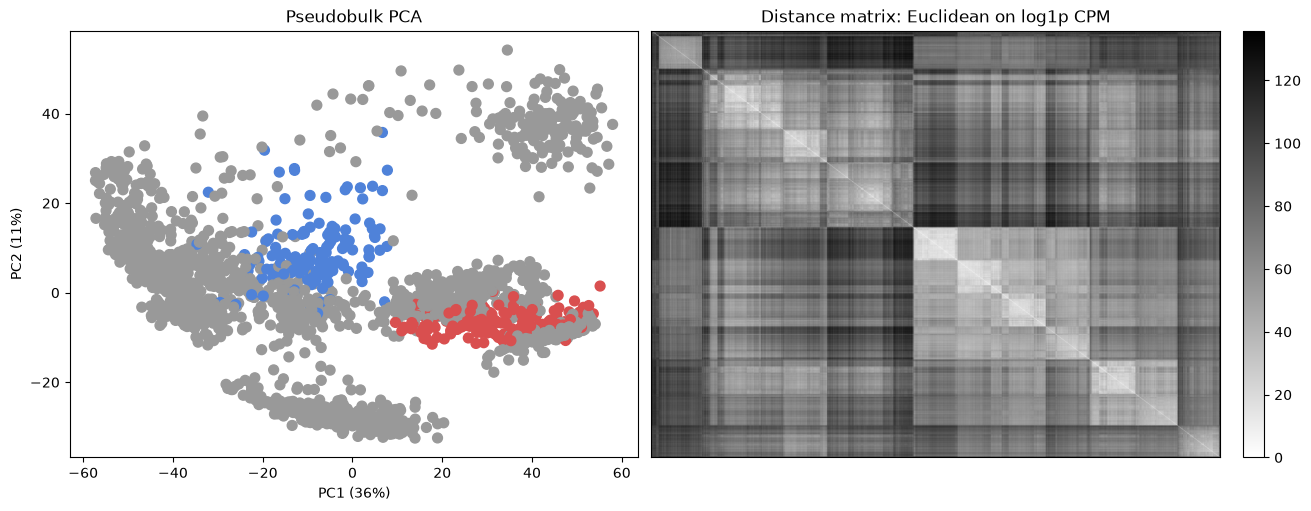

In [ ]:
# PCA and distance matrix diagnostics matching KaroSpace's log1p CPM preprocessing.
counts = np.array(pair_counts, dtype=float, copy=True)
counts[~np.isfinite(counts)] = 0
counts[counts < 0] = 0
library_sizes = counts.sum(axis=1)
safe_libs = np.where(library_sizes > 0, library_sizes, 1.0)
log_cpm = np.log1p((counts / safe_libs[:, None]) * 1_000_000.0)

variances = np.var(log_cpm, axis=0)
finite_var = np.isfinite(variances) & (variances > 0)
feature_idx = (
    np.flatnonzero(finite_var) if finite_var.any() else np.arange(log_cpm.shape[1])
)
if feature_idx.size > int(MAX_DIAGNOSTIC_GENES):
    order = np.argsort(variances[feature_idx])[::-1][: int(MAX_DIAGNOSTIC_GENES)]
    feature_idx = feature_idx[order]

diag_matrix = log_cpm[:, feature_idx]
diag_matrix = diag_matrix - np.nanmean(diag_matrix, axis=0, keepdims=True)
diag_matrix[~np.isfinite(diag_matrix)] = 0

u, s, vt = np.linalg.svd(diag_matrix, full_matrices=False)
scores = u[:, :2] * s[:2]
if scores.shape[1] == 1:
    scores = np.column_stack([scores[:, 0], np.zeros(scores.shape[0])])
eig = s**2
var_explained = eig / eig.sum() if eig.sum() > 0 else np.array([np.nan, np.nan])

condensed = pdist(diag_matrix, metric="euclidean")
dist = squareform(condensed)
leaf_order = (
    leaves_list(linkage(condensed, method="average")).astype(int).tolist()
    if condensed.size
    else list(range(counts.shape[0]))
)
ordered_dist = dist[np.ix_(leaf_order, leaf_order)]

diag_info = pair_meta.copy()
diag_info["library_size"] = library_sizes.astype(int)
diag_info["PC1"] = scores[:, 0]
diag_info["PC2"] = scores[:, 1]
display(diag_info.head(20))

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
group_color = {source: "#d94f4f", reference: "#4f82d9"}
point_colors = [group_color.get(g, "#999999") for g in pair_meta["_pb_group"]]

axes[0].scatter(scores[:, 0], scores[:, 1], c=point_colors, s=50)
axes[0].set_xlabel(
    f"PC1 ({var_explained[0] * 100:.0f}%)" if np.isfinite(var_explained[0]) else "PC1"
)
axes[0].set_ylabel(
    f"PC2 ({var_explained[1] * 100:.0f}%)"
    if len(var_explained) > 1 and np.isfinite(var_explained[1])
    else "PC2"
)
axes[0].set_title("Pseudobulk PCA")

im = axes[1].imshow(ordered_dist, cmap="gray_r", aspect="auto")
axes[1].set_title("Distance matrix: Euclidean on log1p CPM")
axes[1].set_xticks([])
axes[1].set_yticks([])
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
plt.show()

In [ ]:
# Save the audited result table.
# out_csv = Path(H5AD_PATH).with_suffix(f".{GROUPBY}.{source}_vs_{reference}.pseudobulk_audit.csv")
# de_table.to_csv(out_csv, index=False)
# print(out_csv)

## Pathway Enrichment Audit: ORA and Preranked GSEA

This section mirrors the KaroSpace viewer pathway summaries added after Simple design pseudobulk DE. It runs over the formatted `de_table` for the selected `source - reference` contrast.

- ORA is run separately on significant positive and negative DE genes. `MIN_PCT_EXPRESSED` is applied before DeseqStats; ORA then uses genes passing `padj < PADJ_CUTOFF` and `|log2FC| >= LOG2FC_CUTOFF`. The dot plot x-axis is `GeneRatio` (`overlap / query_size`), dot size is the number of overlapping genes, and dot color is `-log10 adjusted p-value`.
- GSEA uses the full ranked gene list retained after DESeq2/model-level gene filtering, not only the significant DE genes. The notebook shows the same enrichment-profile style plot as the viewer for the top retained positive and negative pathways: running ES curve, pathway hit ticks, and ranked metric scores.
- Set `PATHWAY_GMT` to one or more local `.gmt` files for fully offline/reproducible runs. Leave it as `None` to use Reactome through GSEApy, matching the viewer default when `--pathway-gmt` is omitted.


In [27]:
# Pathway enrichment settings: edit this cell if needed.
PATHWAY_GMT = None  # None uses Reactome via GSEApy; or use "reactome.gmt" / ["reactome.gmt", "go_bp.gmt"]
PATHWAY_ORGANISM = "Mouse"
PATHWAY_TOP_N = 20
PATHWAY_MIN_OVERLAP = 3
PATHWAY_MAX_SIZE = 500
PATHWAY_GSEA_PERMUTATIONS = 100  # use 0 for faster ES/NES-only audit
PATHWAY_GSEA_SEED = 0

In [ ]:
# Compute ORA and compact preranked GSEA from the audited DE table.
import sys

repo_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import importlib
import karospace.pathways as pathway_module

# In notebooks, reload this module so rerunning the cell picks up local KaroSpace edits
# without requiring a kernel restart.
pathway_module = importlib.reload(pathway_module)
enrich_pseudobulk_result = pathway_module.enrich_pseudobulk_result
load_pathway_gene_sets = pathway_module.load_pathway_gene_sets

if de_table.empty:
    raise ValueError(
        "de_table is empty; run the DE cells above before pathway enrichment."
    )

pathway_result = {
    "available": True,
    "genes": de_table["gene"].astype(str).tolist(),
    "base_mean": de_table["baseMean"].astype(float).tolist(),
    "log2foldchanges": de_table["log2fc"].astype(float).tolist(),
    "pvals": de_table["pvalue"].astype(float).tolist(),
    "pvals_adj": de_table["padj"].astype(float).tolist(),
    "scores": de_table["score"].astype(float).tolist(),
    "pct_source": de_table["pct_source"].astype(float).tolist(),
    "pct_reference": de_table["pct_reference"].astype(float).tolist(),
    "min_pct_expressed": float(min_pct),
    "padj_cutoff": float(padj_cutoff),
    "log2fc_cutoff": float(log2fc_cutoff),
}

try:
    pathway_gene_sets, pathway_source = load_pathway_gene_sets(
        PATHWAY_GMT,
        organism=PATHWAY_ORGANISM,
    )
except Exception as exc:
    pathway_gene_sets = None
    pathway_source = {
        "available": False,
        "error": str(exc),
    }
    print("Could not load pathway gene sets:")
    print(exc)
    print()
    print(
        "For an offline run, set PATHWAY_GMT to a local Reactome/MSigDB/WikiPathways GMT file and rerun this cell."
    )

if pathway_gene_sets:
    pathway_enrichment = enrich_pseudobulk_result(
        pathway_result,
        pathway_gene_sets,
        top_n=int(PATHWAY_TOP_N),
        min_overlap=int(PATHWAY_MIN_OVERLAP),
        max_pathway_size=int(PATHWAY_MAX_SIZE),
        gsea_permutations=int(PATHWAY_GSEA_PERMUTATIONS),
        seed=int(PATHWAY_GSEA_SEED),
    )
else:
    pathway_enrichment = None

print("Pathway source")
display(pd.DataFrame([pathway_source]))

if not pathway_enrichment:
    print("No pathway enrichment results were produced for this contrast.")
else:
    print(
        f"Tested pathways: {pathway_enrichment['tested_pathways']:,}; "
        f"GSEA ranked universe: {pathway_enrichment['universe_size']:,} genes"
    )

In [ ]:
# Display compact ORA and GSEA result tables while keeping full rows for plotting.
def pathway_rows_df(method, direction):
    rows = (
        []
        if pathway_enrichment is None
        else pathway_enrichment.get(method, {}).get(direction, [])
    )
    return pd.DataFrame(rows)


def pathway_table(df):
    if df is None or df.empty:
        return df
    cols = [
        col
        for col in [
            "term",
            "direction",
            "padj",
            "pval",
            "odds_ratio",
            "nes",
            "es",
            "overlap",
            "query_size",
            "pathway_size",
            "rank_count",
            "peak_rank",
            "zero_cross_rank",
            "genes",
            "leading_edge",
        ]
        if col in df.columns
    ]
    return df[cols]


ora_up = pathway_rows_df("ora", "up")
ora_down = pathway_rows_df("ora", "down")
gsea_positive = pathway_rows_df("gsea", "positive")
gsea_negative = pathway_rows_df("gsea", "negative")

ora_up_table = pathway_table(ora_up)
ora_down_table = pathway_table(ora_down)
gsea_positive_table = pathway_table(gsea_positive)
gsea_negative_table = pathway_table(gsea_negative)

print(f"ORA up pathways favoring {source}")
display(ora_up_table.head(int(PATHWAY_TOP_N)))
print(f"ORA down pathways favoring {reference}")
display(ora_down_table.head(int(PATHWAY_TOP_N)))
print(f"GSEA positive enrichment pathways favoring {source}")
display(gsea_positive_table.head(int(PATHWAY_TOP_N)))
print(f"GSEA negative enrichment pathways favoring {reference}")
display(gsea_negative_table.head(int(PATHWAY_TOP_N)))

for name, df in {
    "gsea_positive": gsea_positive,
    "gsea_negative": gsea_negative,
}.items():
    missing = {"running_profile", "hit_indices", "rank_metric_profile"}.difference(
        df.columns if df is not None else []
    )
    if df is not None and not df.empty and missing:
        print(
            f"Warning: {name} is missing {sorted(missing)}. "
            "Rerun the pathway computation cell above, or restart the kernel if an old KaroSpace module was cached."
        )

ORA up pathways favoring OPC


,term,direction,padj,pval,odds_ratio,overlap,query_size,pathway_size,genes
0,CS DS Degradation,up,0.010302,0.002060,34.862069,4,47,4,"[Cspg4, Cspg5, Ncan, Vcan]"
1,Chondroitin Sulfate Biosynthesis,up,0.010302,0.002060,34.862069,4,47,4,"[Cspg4, Cspg5, Ncan, Vcan]"
2,"Defective CHST14 Causes EDS, Musculocontractur...",up,0.010302,0.002060,34.862069,4,47,4,"[Cspg4, Cspg5, Ncan, Vcan]"
3,Defective CHST3 Causes SEDCJD,up,0.010302,0.002060,34.862069,4,47,4,"[Cspg4, Cspg5, Ncan, Vcan]"
4,Defective CHSY1 Causes TPBS,up,0.010302,0.002060,34.862069,4,47,4,"[Cspg4, Cspg5, Ncan, Vcan]"
5,Dermatan Sulfate Biosynthesis,up,0.010302,0.002060,34.862069,4,47,4,"[Cspg4, Cspg5, Ncan, Vcan]"
6,A Tetrasaccharide Linker Sequence Is Required ...,up,0.021556,0.008622,11.551724,4,47,5,"[Cspg4, Cspg5, Ncan, Vcan]"
7,Chondroitin Sulfate Dermatan Sulfate Metabolism,up,0.021556,0.008622,11.551724,4,47,5,"[Cspg4, Cspg5, Ncan, Vcan]"
8,Defective B3GALT6 Causes EDSP2 and SEMDJL1,up,0.021556,0.008622,11.551724,4,47,5,"[Cspg4, Cspg5, Ncan, Vcan]"
9,Defective B3GAT3 Causes JDSSDHD,up,0.021556,0.008622,11.551724,4,47,5,"[Cspg4, Cspg5, Ncan, Vcan]"


ORA down pathways favoring Schwann cell


,term,direction,padj,pval,odds_ratio,overlap,query_size,pathway_size,genes
0,Non-integrin membrane-ECM Interactions,down,0.011840,0.000515,15.190476,5,24,8,"[Col1a2, Col4a1, Dag1, Hspg2, Itgb4]"
1,Assembly of Collagen Fibrils and Other Multime...,down,0.018084,0.001573,16.639024,4,24,6,"[Col1a2, Col4a1, Itgb4, Plec]"
2,Extracellular Matrix Organization,down,0.019497,0.002631,5.666667,7,24,20,"[Adam10, Col1a2, Col4a1, Dag1, Hspg2, Itgb4, P..."
3,Collagen Formation,down,0.019497,0.003391,11.822300,4,24,7,"[Col1a2, Col4a1, Itgb4, Plec]"
4,Collagen Degradation,down,0.021107,0.004588,20.674419,3,24,4,"[Adam10, Col1a2, Col4a1]"
5,Degradation of the Extracellular Matrix,down,0.024022,0.006267,9.146341,4,24,8,"[Adam10, Col1a2, Col4a1, Hspg2]"
6,Integrin Cell Surface Interactions,down,0.034895,0.010620,12.339535,3,24,5,"[Col1a2, Col4a1, Hspg2]"
7,Laminin Interactions,down,0.056546,0.019668,8.767442,3,24,6,"[Col4a1, Hspg2, Itgb4]"
8,EGR2 and SOX10-mediated Initiation of Schwann ...,down,0.074320,0.031876,6.782946,3,24,7,"[Dag1, Pmp22, Utrn]"
9,ECM Proteoglycans,down,0.074320,0.032313,4.738881,4,24,12,"[Col1a2, Col4a1, Dag1, Hspg2]"


GSEA positive enrichment pathways favoring OPC


,term,direction,padj,pval,nes,es,overlap,pathway_size,rank_count,peak_rank,zero_cross_rank,leading_edge
0,Neuronal System,positive,0.364922,0.019802,1.635260,0.610750,12,12,215,51,128,"[Gria4, Mapt, Ppfibp1, Nlgn3, Gria2, Gabbr1, K..."
1,Protein-protein Interactions at Synapses,positive,0.364922,0.019802,1.517683,0.795291,4,4,215,31,128,"[Gria4, Ppfibp1, Nlgn3]"
2,Dermatan Sulfate Biosynthesis,positive,0.510891,0.039604,1.365281,0.732921,4,4,215,33,128,"[Cspg5, Ncan, Vcan]"
3,"Defective CHST14 Causes EDS, Musculocontractur...",positive,0.510891,0.039604,1.345315,0.732921,4,4,215,33,128,"[Cspg5, Ncan, Vcan]"
4,Neurotransmitter Receptors and Postsynaptic Si...,positive,0.533212,0.069307,1.469353,0.580554,9,9,215,51,128,"[Gria4, Mapt, Gria2, Gabbr1, Kcnj10]"
5,Cardiac Conduction,positive,0.533212,0.049505,1.396279,0.710900,4,4,215,64,128,"[Kcnip3, Atp2a2, Atp1b2, Hipk2]"
6,Activation of NMDA Receptors and Postsynaptic ...,positive,0.533212,0.049505,1.361520,0.702148,5,5,215,32,128,"[Gria4, Mapt, Gria2]"
7,Defective CHSY1 Causes TPBS,positive,0.533212,0.089109,1.350013,0.732921,4,4,215,33,128,"[Cspg5, Ncan, Vcan]"
8,Chondroitin Sulfate Biosynthesis,positive,0.533212,0.049505,1.328500,0.732921,4,4,215,33,128,"[Cspg5, Ncan, Vcan]"
9,Defective CHST3 Causes SEDCJD,positive,0.533212,0.069307,1.313705,0.732921,4,4,215,33,128,"[Cspg5, Ncan, Vcan]"


GSEA negative enrichment pathways favoring Schwann cell


,term,direction,padj,pval,nes,es,overlap,pathway_size,rank_count,peak_rank,zero_cross_rank,leading_edge
0,Degradation of the Extracellular Matrix,negative,0.319307,0.009901,-2.141598,-0.904247,8,8,215,195,128,"[Capn2, Lamc1, Col4a1, Adam10, Hspg2, Col1a2]"
1,Assembly of Collagen Fibrils and Other Multime...,negative,0.319307,0.009901,-2.100213,-0.872584,6,6,215,198,128,"[Itgb4, Plec, Col4a1, Col1a2]"
2,Extracellular Matrix Organization,negative,0.319307,0.009901,-2.094430,-0.594302,20,20,215,181,128,"[Itgb1, P4hb, Capn2, Lamc1, Itgb4, Plec, Col4a..."
3,Non-integrin membrane-ECM Interactions,negative,0.319307,0.009901,-2.066688,-0.866655,8,8,215,196,128,"[Lamc1, Itgb4, Col4a1, Hspg2, Dag1, Col1a2]"
4,Collagen Degradation,negative,0.319307,0.009901,-1.965126,-0.928609,4,4,215,203,128,"[Col4a1, Adam10, Col1a2]"
5,EGR2 and SOX10-mediated Initiation of Schwann ...,negative,0.319307,0.009901,-1.928113,-0.841490,7,7,215,196,128,"[Lamc1, Dag1, Pmp22, Utrn]"
6,Laminin Interactions,negative,0.319307,0.009901,-1.903236,-0.845881,6,6,215,181,128,"[Itgb1, Lamc1, Itgb4, Col4a1, Hspg2]"
7,Collagen Biosynthesis and Modifying Enzymes,negative,0.319307,0.009901,-1.823817,-0.841549,4,4,215,184,128,"[P4hb, Col4a1, Col1a2]"
8,Integrin Cell Surface Interactions,negative,0.319307,0.009901,-1.821541,-0.840528,5,5,215,181,128,"[Itgb1, Col4a1, Hspg2, Col1a2]"
9,Signaling by TGFB Family Members,negative,0.319307,0.009901,-1.750882,-0.832119,5,5,215,180,128,"[Rhoa, Itgb1, Tgfbr3, Col1a2]"


In [ ]:
# Plot ORA dot plots and classic GSEA enrichment profiles, matching the viewer summaries.
from matplotlib.colors import LinearSegmentedColormap, Normalize


def _short_term(value, max_len=58):
    text = str(value or "")
    return text if len(text) <= max_len else text[: max_len - 1] + "…"


def _empty_axis(ax, title, message="No pathways"):
    ax.axis("off")
    ax.set_title(title)
    ax.text(0.5, 0.5, message, ha="center", va="center", transform=ax.transAxes)


def _score_norm(values):
    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return Normalize(vmin=0.0, vmax=1.0)
    vmin = float(np.nanmin(arr))
    vmax = float(np.nanmax(arr))
    if np.isclose(vmin, vmax):
        return Normalize(vmin=max(0.0, vmin * 0.5), vmax=vmax * 1.5 + 1e-12)
    return Normalize(vmin=vmin, vmax=vmax)


def plot_ora_dotplot(ax, df, title):
    if df is None or df.empty:
        _empty_axis(ax, title)
        return
    plot_df = df.copy()
    plot_df["overlap_n"] = pd.to_numeric(plot_df["overlap"], errors="coerce").fillna(
        0.0
    )
    plot_df["query_size_n"] = pd.to_numeric(
        plot_df["query_size"], errors="coerce"
    ).replace(0, np.nan)
    plot_df["gene_ratio"] = np.divide(
        plot_df["overlap_n"].to_numpy(dtype=float),
        plot_df["query_size_n"].to_numpy(dtype=float),
        out=np.zeros(len(plot_df), dtype=float),
        where=np.isfinite(plot_df["query_size_n"].to_numpy(dtype=float)),
    )
    plot_df["padj_n"] = (
        pd.to_numeric(plot_df["padj"], errors="coerce")
        .fillna(1.0)
        .clip(np.nextafter(0.0, 1.0), 1.0)
    )
    plot_df["neg_log10_padj"] = -np.log10(plot_df["padj_n"])
    plot_df = (
        plot_df.sort_values(
            ["gene_ratio", "padj_n", "term"], ascending=[False, True, True]
        )
        .head(12)
        .sort_values("gene_ratio", ascending=True)
    )

    overlap = plot_df["overlap_n"].to_numpy(dtype=float)
    gene_ratio = plot_df["gene_ratio"].to_numpy(dtype=float)
    score = plot_df["neg_log10_padj"].to_numpy(dtype=float)
    size_range = max(float(np.nanmax(overlap) - np.nanmin(overlap)), 1.0)
    sizes = (
        55.0
        + np.sqrt(np.maximum(overlap - np.nanmin(overlap), 0.0) / size_range) * 260.0
    )
    y = np.arange(len(plot_df))
    scatter = ax.scatter(
        gene_ratio,
        y,
        s=sizes,
        c=score,
        cmap="viridis",
        norm=_score_norm(score),
        edgecolors="none",
        alpha=0.9,
    )
    ax.set_yticks(y)
    ax.set_yticklabels([_short_term(term) for term in plot_df["term"]], fontsize=8)
    ax.set_xlabel("GeneRatio")
    ax.set_title(title)
    ax.grid(axis="x", color="0.9", linewidth=0.8)
    cbar = plt.colorbar(scatter, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("-log10 adjusted p")

    unique_sizes = np.unique(overlap.astype(int))
    if unique_sizes.size:
        legend_values = np.unique(
            np.round(
                np.linspace(
                    unique_sizes.min(), unique_sizes.max(), min(3, unique_sizes.size)
                )
            ).astype(int)
        )
        handles = []
        labels = []
        for value in legend_values:
            radius_size = (
                55.0
                + np.sqrt(max(value - np.nanmin(overlap), 0.0) / size_range) * 260.0
            )
            handles.append(
                ax.scatter([], [], s=radius_size, facecolors="none", edgecolors="0.35")
            )
            labels.append(str(int(value)))
        ax.legend(
            handles,
            labels,
            title="genes",
            loc="lower right",
            frameon=False,
            fontsize=8,
            title_fontsize=8,
        )


def _to_numeric_profile(values):
    if not isinstance(values, (list, tuple)) or len(values) == 0:
        return np.empty((0, 2), dtype=float)
    arr = np.asarray(values, dtype=float)
    if arr.ndim != 2 or arr.shape[1] < 2:
        return np.empty((0, 2), dtype=float)
    return arr[:, :2]


def _scale_to_band(values, low, high, include_zero=True):
    arr = np.asarray(values, dtype=float)
    finite = arr[np.isfinite(arr)]
    if include_zero:
        finite = np.concatenate([finite, np.array([0.0])])
    if finite.size == 0:
        return np.full_like(arr, (low + high) / 2.0, dtype=float)
    vmin = float(np.nanmin(finite))
    vmax = float(np.nanmax(finite))
    if np.isclose(vmin, vmax):
        return np.full_like(arr, (low + high) / 2.0, dtype=float)
    return low + (arr - vmin) / (vmax - vmin) * (high - low)


def _fmt_number(value):
    try:
        number = float(value)
    except (TypeError, ValueError):
        return "n/a"
    return f"{number:.3g}" if np.isfinite(number) else "n/a"


def plot_gsea_enrichment(
    ax, df, title, primary_color="#d94f4f", secondary_color="#4f82d9"
):
    if df is None or df.empty:
        _empty_axis(ax, title)
        return
    row = df.iloc[0].to_dict()
    profile = _to_numeric_profile(row.get("running_profile"))
    metric = _to_numeric_profile(row.get("rank_metric_profile"))
    hits = np.asarray(row.get("hit_indices") or [], dtype=float)
    rank_count = int(row.get("rank_count") or 0)
    if profile.size == 0 or metric.size == 0 or hits.size == 0 or rank_count < 2:
        _empty_axis(ax, title, message="No GSEA profile data")
        return

    direction = str(row.get("direction", "positive"))
    direction_positive = direction != "negative"
    display_sign = 1.0 if direction_positive else -1.0
    profile_values = display_sign * profile[:, 1]
    metric_values = display_sign * metric[:, 1]
    display_profile_x = (
        profile[:, 0] if direction_positive else (rank_count - 1) - profile[:, 0]
    )
    display_metric_x = (
        metric[:, 0] if direction_positive else (rank_count - 1) - metric[:, 0]
    )
    display_hits = hits if direction_positive else (rank_count - 1) - hits
    profile_color = primary_color if direction_positive else secondary_color
    opposite_color = secondary_color if direction_positive else primary_color
    label_a = source if direction_positive else reference
    label_b = reference if direction_positive else source
    term = _short_term(row.get("term"), max_len=60)
    ax.set_title(f"{title}: {term}", fontsize=10)
    ax.set_xlim(0, rank_count - 1)
    ax.set_ylim(0, 1)
    ax.set_yticks([])
    ax.set_xlabel("Rank in ordered dataset")
    for spine in ["left", "right", "top"]:
        ax.spines[spine].set_visible(False)

    es_low, es_high = 0.63, 0.98
    hit_low, hit_high = 0.45, 0.58
    metric_low, metric_high = 0.08, 0.38
    for low, high in [
        (es_low, es_high),
        (hit_low, hit_high),
        (metric_low, metric_high),
    ]:
        ax.axhspan(low, high, color="none", ec="0.82", lw=0.8)
        for frac in [0.25, 0.5, 0.75]:
            ax.axhline(
                low + (high - low) * frac, color="0.9", lw=0.7, ls="--", zorder=0
            )

    es_y = _scale_to_band(profile_values, es_low, es_high)
    zero_es = _scale_to_band(np.array([0.0]), es_low, es_high)[0]
    ax.axhline(zero_es, color="0.65", lw=0.8)
    profile_order = np.argsort(display_profile_x)
    ax.plot(
        display_profile_x[profile_order],
        es_y[profile_order],
        color=profile_color,
        lw=2.2,
        solid_joinstyle="round",
    )
    peak_rank = row.get("peak_rank")
    if pd.notna(peak_rank):
        display_peak = (
            float(peak_rank)
            if direction_positive
            else (rank_count - 1) - float(peak_rank)
        )
        ax.axvline(
            display_peak,
            ymin=es_low,
            ymax=es_high,
            color=profile_color,
            lw=0.9,
            ls="--",
            alpha=0.35,
        )

    for hit in display_hits:
        ax.vlines(hit, hit_low + 0.01, hit_high - 0.01, color="black", lw=0.8)
    cmap = LinearSegmentedColormap.from_list(
        "gsea_direction", [profile_color, "#f5f5f5", opposite_color]
    )
    ax.imshow(
        np.linspace(0, 1, 256).reshape(1, -1),
        extent=[0, rank_count - 1, hit_low - 0.035, hit_low - 0.005],
        aspect="auto",
        cmap=cmap,
        interpolation="nearest",
    )

    metric_y = _scale_to_band(metric_values, metric_low, metric_high)
    zero_metric = _scale_to_band(np.array([0.0]), metric_low, metric_high)[0]
    ax.axhline(zero_metric, color="0.65", lw=0.8)
    metric_order = np.argsort(display_metric_x)
    ax.vlines(
        display_metric_x[metric_order],
        zero_metric,
        metric_y[metric_order],
        color="0.72",
        lw=1.2,
        alpha=0.9,
    )
    zero_cross = row.get("zero_cross_rank")
    if pd.notna(zero_cross):
        display_zero = (
            float(zero_cross)
            if direction_positive
            else (rank_count - 1) - float(zero_cross)
        )
        ax.axvline(
            display_zero,
            ymin=metric_low,
            ymax=metric_high,
            color="0.5",
            lw=0.9,
            ls="--",
        )
        ax.text(
            display_zero,
            metric_low + 0.02,
            "Zero cross",
            ha="center",
            va="bottom",
            fontsize=8,
            color="0.35",
        )

    ax.text(
        -0.03,
        (es_low + es_high) / 2,
        "ES",
        ha="right",
        va="center",
        rotation=90,
        transform=ax.transAxes,
        fontsize=9,
    )
    ax.text(
        -0.03,
        (metric_low + metric_high) / 2,
        "Rank metric",
        ha="right",
        va="center",
        rotation=90,
        transform=ax.transAxes,
        fontsize=9,
    )
    ax.text(
        0.01,
        hit_low - 0.055,
        f"{label_a} enriched",
        color=profile_color,
        ha="left",
        va="top",
        transform=ax.transAxes,
        fontsize=8,
    )
    ax.text(
        0.99,
        hit_low - 0.055,
        f"{label_b} enriched",
        color=opposite_color,
        ha="right",
        va="top",
        transform=ax.transAxes,
        fontsize=8,
    )
    ax.text(
        0.01,
        0.01,
        f"NES={_fmt_number(abs(row.get('nes')))}; ES={_fmt_number(abs(row.get('es')))}; adj. p={_fmt_number(row.get('padj'))}",
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=8,
        color="0.35",
    )


fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), constrained_layout=True)
plot_ora_dotplot(axes[0], ora_up, f"ORA up: {source}")
plot_ora_dotplot(axes[1], ora_down, f"ORA down: {reference}")
plt.show()


def _gsea_dropdown_rows():
    frames = []
    if gsea_positive is not None and not gsea_positive.empty:
        frames.append(gsea_positive.assign(gsea_direction_label=f"{source} enriched"))
    if gsea_negative is not None and not gsea_negative.empty:
        frames.append(
            gsea_negative.assign(gsea_direction_label=f"{reference} enriched")
        )
    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True)


gsea_dropdown_df = _gsea_dropdown_rows()


def _plot_selected_gsea_pathway(row_index):
    row_index = int(row_index)
    selected = gsea_dropdown_df.iloc[[row_index]]
    fig, ax = plt.subplots(1, 1, figsize=(12, 6), constrained_layout=True)
    direction = selected.iloc[0].get("gsea_direction_label", "GSEA")
    plot_gsea_enrichment(
        ax, selected, str(direction), primary_color="#d94f4f", secondary_color="#4f82d9"
    )
    plt.show()


if gsea_dropdown_df.empty:
    print("No GSEA pathways available for the dropdown.")
else:
    options = []
    for idx, row in gsea_dropdown_df.iterrows():
        nes = _fmt_number(abs(row.get("nes")))
        padj = _fmt_number(row.get("padj"))
        label = f"{row.get('gsea_direction_label')}: {_short_term(row.get('term'), 72)} | NES={nes}, adj. p={padj}"
        options.append((label, int(idx)))
    try:
        import ipywidgets as widgets
        from IPython.display import display

        selector = widgets.Dropdown(
            options=options, description="Pathway:", layout=widgets.Layout(width="100%")
        )
        output = widgets.interactive_output(
            _plot_selected_gsea_pathway, {"row_index": selector}
        )
        display(widgets.VBox([selector, output]))
    except Exception as exc:
        print(
            "ipywidgets is unavailable; showing the first retained GSEA pathway instead."
        )
        print(exc)
        _plot_selected_gsea_pathway(options[0][1])

In [ ]:
# Optional: save pathway tables next to the audited DE table.
# pathway_prefix = Path(H5AD_PATH).with_suffix(f".{GROUPBY}.{source}_vs_{reference}.pathway")
# for name, df in {
#     "ora_up": ora_up_table,
#     "ora_down": ora_down_table,
#     "gsea_positive": gsea_positive_table,
#     "gsea_negative": gsea_negative_table,
# }.items():
#     if df is not None and not df.empty:
#         out_path = pathway_prefix.with_suffix(f".{name}.csv")
#         df.to_csv(out_path, index=False)
#         print(out_path)